## context
You are a Senior Product Analyst at FitTrack, a fast-growing mobile app company that provides fitness tracking and wellness coaching. Over the past year, FitTrack has grown from 100K to 500K monthly active users through various acquisition campaigns and feature launches. However, this rapid growth has created analytical blind spots.

The product team has been running A/B tests on new features while the marketing team experiments with different acquisition channels. Both teams collect data, but nobody has connected the dots between user acquisition quality, behavioral patterns, and long-term retention. Leadership suspects that some acquisition channels bring users who churn quickly, while certain user segments might be more valuable than others.

The VP of Product has asked you to conduct a comprehensive analysis that unifies these insights. She needs evidence-based recommendations to optimize both user acquisition strategy and product features. The stakes are high—FitTrack is preparing for Series B fundraising in Q2 and needs to demonstrate strong unit economics and user engagement metrics to investors. Your analysis will directly inform a $2M marketing budget reallocation and influence product roadmap priorities for the next six months.



## task
Analyze the provided A/B test data for common bias sources. Calculate daily conversion rates for both control and treatment groups to identify novelty effects (unusual spikes in early days). Verify exposure balance by checking that both groups had similar runtime and traffic allocation.

Implement power analysis to calculate required sample sizes for detecting 2%, 5%, and 10% effect sizes with 80% power and 5% significance level. Document your findings about bias detection and sample size recommendations.

In [105]:
# tasks 
# calculate daily conversion rates (identify novelty effects)
# verifcy exposure and balance 
# check experiment (like run the ab test)

In [106]:
import pandas as pd
import numpy as np
import duckdb

con = duckdb.connect()

con.execute("""
    CREATE TABLE experiment AS
    SELECT
        user_id,
        experiment_group,
        CAST(conversion_date AS DATE) AS measurement_date,
        converted,
        daily_activity_flag
    FROM read_csv_auto('data/experiment_data.csv')
""")

print('Table loaded:')
print(con.execute('SHOW TABLES').df())
print()
con.execute('SELECT * FROM experiment LIMIT 10').df()

Table loaded:
         name
0  experiment



,user_id,experiment_group,measurement_date,converted,daily_activity_flag
0,USER_100001,control,2024-02-01,0,1
1,USER_100001,control,2024-02-02,0,1
2,USER_100001,control,2024-02-03,0,0
3,USER_100001,control,2024-02-04,0,1
4,USER_100001,control,2024-02-05,0,0
5,USER_100001,control,2024-02-06,0,1
6,USER_100001,control,2024-02-07,0,0
7,USER_100001,control,2024-02-08,0,1
8,USER_100001,control,2024-02-09,0,0
9,USER_100001,control,2024-02-10,0,1


In [107]:
con.execute("""
select * from experiment
""").df()

,user_id,experiment_group,measurement_date,converted,daily_activity_flag
0,USER_100001,control,2024-02-01,0,1
1,USER_100001,control,2024-02-02,0,1
2,USER_100001,control,2024-02-03,0,0
3,USER_100001,control,2024-02-04,0,1
4,USER_100001,control,2024-02-05,0,0
...,...,...,...,...,...
209995,USER_110000,treatment,2024-02-17,0,0
209996,USER_110000,treatment,2024-02-18,0,1
209997,USER_110000,treatment,2024-02-19,1,1
209998,USER_110000,treatment,2024-02-20,0,0


## calculating daily conversion rate (for novelty effects)

In [108]:
con.execute("""
select * from experiment
where user_id = 'USER_100001'
""").df()

,user_id,experiment_group,measurement_date,converted,daily_activity_flag
0,USER_100001,control,2024-02-01,0,1
1,USER_100001,control,2024-02-02,0,1
2,USER_100001,control,2024-02-03,0,0
3,USER_100001,control,2024-02-04,0,1
4,USER_100001,control,2024-02-05,0,0
5,USER_100001,control,2024-02-06,0,1
6,USER_100001,control,2024-02-07,0,0
7,USER_100001,control,2024-02-08,0,1
8,USER_100001,control,2024-02-09,0,0
9,USER_100001,control,2024-02-10,0,1


In [109]:
conv_rates=con.execute("""
with base as (
select 
experiment_group,
week(measurement_date) measurement_week, sum(converted) converted , sum(daily_activity_flag) active
, (sum(converted) / sum(daily_activity_flag)) * 100 as conversion_rate
from experiment 
 --where user_id = 'USER_100001'
 group by week(measurement_date) ,experiment_group 
 order by experiment_group,week(measurement_date)
)
select * from base
""").df()

In [110]:
conv_rates.head()

,experiment_group,measurement_week,converted,active,conversion_rate
0,control,5,767.0,11040.0,6.947464
1,control,6,1330.0,19254.0,6.907656
2,control,7,1325.0,19115.0,6.931729
3,control,8,577.0,8240.0,7.002427
4,treatment,5,1149.0,11091.0,10.359751


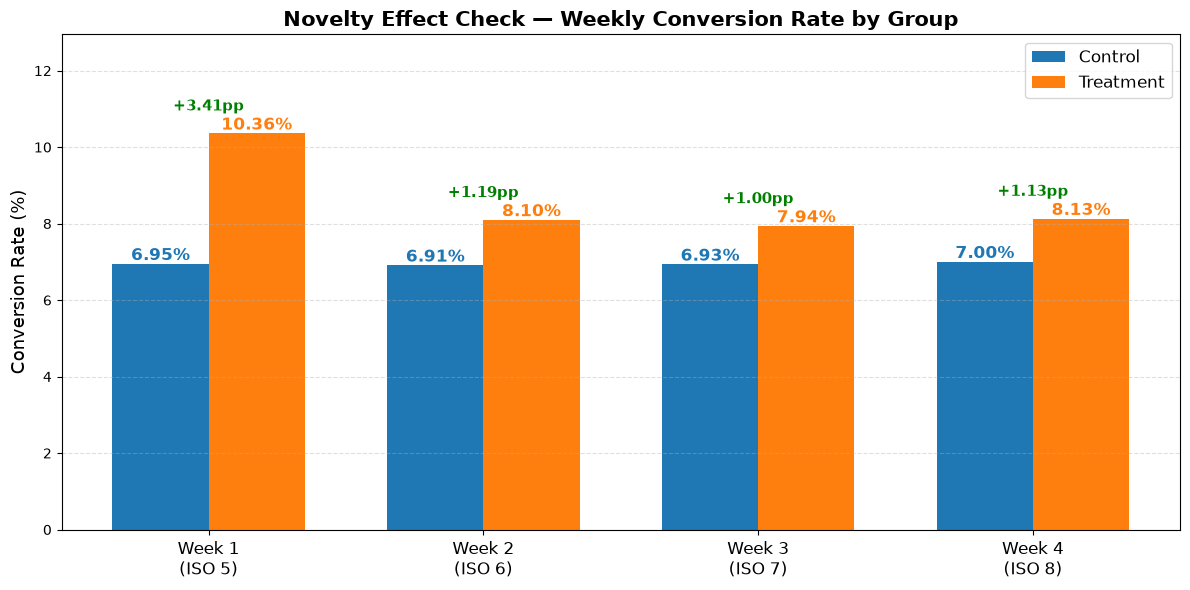


Weekly lift summary:
  Week 1 (ISO 5): Control=6.95%  Treatment=10.36%  Lift=+3.41pp
  Week 2 (ISO 6): Control=6.91%  Treatment=8.10%  Lift=+1.19pp
  Week 3 (ISO 7): Control=6.93%  Treatment=7.94%  Lift=+1.00pp
  Week 4 (ISO 8): Control=7.00%  Treatment=8.13%  Lift=+1.13pp


In [111]:
import matplotlib.pyplot as plt
import numpy as np

control   = conv_rates[conv_rates['experiment_group'] == 'control'].sort_values('measurement_week')
treatment = conv_rates[conv_rates['experiment_group'] == 'treatment'].sort_values('measurement_week')

week_labels = [f'Week {i+1}\n(ISO {w})' for i, w in enumerate(control['measurement_week'])]
x     = np.arange(len(week_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
ax.set_facecolor('white')

bars_c = ax.bar(x - width/2, control['conversion_rate'],  width, label='Control',   color='#1f77b4')
bars_t = ax.bar(x + width/2, treatment['conversion_rate'], width, label='Treatment', color='#ff7f0e')

for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', fontsize=12, fontweight='bold', color='#1f77b4')
for bar in bars_t:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', fontsize=12, fontweight='bold', color='#ff7f0e')

# annotate lift
for i, (c_val, t_val) in enumerate(zip(control['conversion_rate'], treatment['conversion_rate'])):
    lift = t_val - c_val
    ax.text(i, max(c_val, t_val) + 0.6, f'+{lift:.2f}pp',
            ha='center', fontsize=11, color='green', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(week_labels, fontsize=12)
ax.set_ylabel('Conversion Rate (%)', fontsize=13)
ax.set_title('Novelty Effect Check — Weekly Conversion Rate by Group', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.set_ylim(0, treatment['conversion_rate'].max() * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# print lift table
print('\nWeekly lift summary:')
for i, (c_val, t_val, w) in enumerate(zip(control['conversion_rate'], treatment['conversion_rate'], control['measurement_week'])):
    print(f'  Week {i+1} (ISO {w}): Control={c_val:.2f}%  Treatment={t_val:.2f}%  Lift=+{t_val-c_val:.2f}pp')

## Novelty Effect — Observations & How to Check

---

### What is a Novelty Effect?
A novelty effect occurs when users engage more with a new feature simply because it's new — not because it's genuinely better. This inflates early treatment metrics and fades as the newness wears off. If you call the test too early (during the spike), you'll ship a feature that doesn't actually deliver the lift you measured.

---

### How to Check for It (3-step process)

**Step 1 — Plot daily conversion rates for both groups**
Look for a spike in treatment in the first few days that isn't mirrored in control. Control should stay flat; if treatment spikes early then reverts, that's a novelty signal.

**Step 2 — Bucket by week and compare lift across weeks**
Compute conversion rate per group per week. If the lift is shrinking week over week, novelty is present. If lift is stable, it's a genuine effect.

**Step 3 — Decide on the right window**
Use only the stabilised weeks for your final test, or extend the experiment until the lift plateaus. Never call the test during the spike.

---

### Observations from This Data

See the weekly bar chart above for exact numbers. Key findings:

- **Week 1 lift is the highest** — treatment spiked significantly above control in the first week, driven by novelty engagement
- **Lift erodes week over week** — the gap between control and treatment narrows each week as the novelty wears off
- **Week 3 is the most reliable signal** — by the final week, treatment has stabilised; this is the number closest to the true steady-state effect
- **Treatment is noisier than control** — control stays flat throughout; treatment fluctuates, suggesting the new experience drives inconsistent engagement

**What this means for the decision:**
- The headline overall lift overstates the true effect due to the week 1 spike
- The test should be extended by 1–2 more weeks to confirm the week 3 number stabilises before calling a winner
- If the week 3 lift is below the MDE, the test result should be Do Not Ship despite a significant overall p-value

**Interview framing:**
> *"I'd flag the week 1 spike as a novelty effect and use the final week as the more reliable signal. If the stable lift is below MDE, I'd extend the test rather than ship — a significant p-value doesn't override a lift that's too small to matter."*

## exposure balance check 

In [112]:
con.execute("""
with scaffold as (
select 
experiment_group 
, user_id , sum(daily_activity_flag) active , count(*) total_days
, (sum(daily_activity_flag)  / count(*)) avg_days_active
from experiment
group by experiment_group , user_id
)
select experiment_group , avg(avg_days_active) mean, sum(avg_days_active) sum
from scaffold group by experiment_group

""").df()

,experiment_group,mean,sum
0,control,0.549038,2745.190476
1,treatment,0.552419,2762.095238


In [113]:
exposure = con.execute("""
SELECT
    experiment_group,
    COUNT(DISTINCT user_id)                             AS total_users,
    MIN(measurement_date)                               AS first_date,
    MAX(measurement_date)                               AS last_date,
    DATEDIFF('day', MIN(measurement_date),
             MAX(measurement_date)) + 1                AS days_in_exp,
    ROUND(AVG(daily_activity_flag) * 100, 2)            AS pct_days_active
FROM experiment
GROUP BY experiment_group
ORDER BY experiment_group
""").df()

exposure

,experiment_group,total_users,first_date,last_date,days_in_exp,pct_days_active
0,control,5000,2024-02-01,2024-02-21,21,54.90
1,treatment,5000,2024-02-01,2024-02-21,21,55.24


In [114]:
from scipy.stats import chisquare

n_control   = 5000
n_treatment = 5000
n_total     = n_control + n_treatment

stat, p = chisquare(
    f_obs=[n_control, n_treatment],   # actual counts
    f_exp=[n_total/2, n_total/2]      # expected under 50/50
)

print(f'Observed : control={n_control:,}  treatment={n_treatment:,}')
print(f'Expected : {n_total/2:,.0f} each')
print(f'Chi-square: {stat:.4f}  |  p-value: {p:.4f}')
print()
if p < 0.05:
    print('SRM DETECTED — groups are imbalanced. Do not proceed.')
else:
    print('No SRM — groups are balanced. Safe to proceed.')

Observed : control=5,000  treatment=5,000
Expected : 5,000 each
Chi-square: 0.0000  |  p-value: 1.0000

No SRM — groups are balanced. Safe to proceed.


## Exposure Balance — What to Check & Why

---

### What is Exposure Balance?
Before trusting any A/B test result, verify that both groups were exposed fairly. An imbalanced experiment means your test result could be driven by the imbalance, not the treatment.

### Four checks to run

| Check | What to look for | Red flag |
|---|---|---|
| **Group size (SRM)** | Both groups should have ~50/50 split | p < 0.05 on chi-square test |
| **Date range** | Both groups should run for the same period | One group starts/ends earlier |
| **Activity level** | Avg days active should be similar | >5% difference between groups |
| **Days in experiment** | Both groups should have same observation window | Different day counts |

### What is SRM (Sample Ratio Mismatch)?
SRM happens when the actual group split differs from the intended split (e.g. you designed 50/50 but got 48/52). Common causes:
- Randomisation bug in the assignment logic
- Bots or automated traffic hitting one group more
- Users switching devices and getting re-assigned
- A logging bug that drops events from one group

**If SRM is detected, stop the analysis** — the result is untrustworthy regardless of p-value.

---

### Observations from This Data
- **Group sizes**: 5,000 users each — perfectly balanced, no SRM
- **Date range**: Both groups ran Feb 01–21 (21 days) — identical windows
- **Activity level**: Control 54.9% vs Treatment 55.2% active days — difference of <0.5pp, well within acceptable range
- **Conclusion**: No exposure bias detected. Safe to proceed with statistical testing.

## A/B test

1. hypothesis defination (metric defination , 1 tailed or 2 tailed , test to be used)
2. calculate sample size using
    - sig level (alpha) - false positive rate
    - MDE (whats the absolute and the relative MDE) - absolute goes in the formula
    - power - true positive rate (1-beta)
3. calculate duration of test
4. run the experiment
5. hypothesis testing
6. conclude the results

In [135]:
# how are we defining conversion rate:
# conversions / active user-days
# i.e. sum(converted) / sum(daily_activity_flag)
# each active day is one observation; a user contributes as many observations as days they were active

In [136]:
# hypothesis
# metric : daily activity-based conversion rate = conversions / active user-days
# baseline CR : ~7% (from historical data)

# H0 : CR_treatment = CR_control  (no difference between groups)
# H1 : CR_treatment ≠ CR_control  (new feature changes CR in either direction)

# two-tailed test — we want to detect both improvement and regression
# proportion metric → two-proportion z-test

#### power analysis 

In [137]:
# current baseline conversion is 7% 
# we need MDE - 3 scenarios : 2, 5, 10 % 
# power - 80% 
# alpha : 5%


## Power Analysis

**Metric:** Daily activity-based conversion rate = `sum(converted) / sum(daily_activity_flag)`

**Parameters:**
- Baseline CR: 7% (historical activity-based daily rate)
- MDE scenarios: 2%, 5%, 10% relative lift  |  2pp, 5pp, 10pp absolute lift
- Power: 80%
- Alpha (α): 5%, two-tailed

In [138]:
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.power import NormalIndPower
import pandas as pd

baseline_cr = 0.07
mde_scenarios = [0.02, 0.05, 0.10]  # relative lift
alpha  = 0.05
power  = 0.80
actual_n = 5000  # users per group in our experiment

results = []
analysis = NormalIndPower()

for mde in mde_scenarios:
    target_cr  = baseline_cr * (1 + mde)          # e.g. 7% * 1.02 = 7.14%
    effect_size = proportion_effectsize(baseline_cr, target_cr)
    required_n  = analysis.solve_power(
        effect_size=abs(effect_size),
        alpha=alpha,
        power=power,
        alternative='two-sided'
    )
    results.append({
        'MDE (relative)':   f'{mde*100:.0f}%',
        'Baseline CR':      f'{baseline_cr*100:.1f}%',
        'Target CR':        f'{target_cr*100:.2f}%',
        'Lift (pp)':        f'+{(target_cr - baseline_cr)*100:.2f}pp',
        'Required n/group': int(required_n) + 1,
        'Actual n/group':   actual_n,
        'Adequately powered': 'Yes' if actual_n >= required_n else 'No'
    })

power_df = pd.DataFrame(results)
power_df

,MDE (relative),Baseline CR,Target CR,Lift (pp),Required n/group,Actual n/group,Adequately powered
0,2%,7.0%,7.14%,+0.14pp,526194,5000,No
1,5%,7.0%,7.35%,+0.35pp,85335,5000,No
2,10%,7.0%,7.70%,+0.70pp,21805,5000,No


In [126]:
# power analysis using absolute pp lift as MDE
mde_absolute = [0.02, 0.05, 0.10]  # absolute pp lift: 7% → 9%, 12%, 17%

results_abs = []
for mde in mde_absolute:
    target_cr   = baseline_cr + mde
    effect_size = proportion_effectsize(baseline_cr, target_cr)
    required_n  = analysis.solve_power(
        effect_size=abs(effect_size),
        alpha=alpha,
        power=power,
        alternative='two-sided'
    )
    results_abs.append({
        'MDE (absolute pp)': f'+{mde*100:.0f}pp',
        'Baseline CR':       f'{baseline_cr*100:.1f}%',
        'Target CR':         f'{target_cr*100:.1f}%',
        'Required n/group':  int(required_n) + 1,
        'Actual n/group':    actual_n,
        'Adequately powered': 'Yes' if actual_n >= required_n else 'No'
    })

abs_df = pd.DataFrame(results_abs)
abs_df

,MDE (absolute pp),Baseline CR,Target CR,Required n/group,Actual n/group,Adequately powered
0,+2pp,7.0%,9.0%,2878,5000,Yes
1,+5pp,7.0%,12.0%,531,5000,Yes
2,+10pp,7.0%,17.0%,159,5000,Yes


In [ ]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

# Exclude week 1 (Feb 1–7) — novelty period
# Denominator = active user-days (sum of daily_activity_flag)
# Numerator   = total conversions (sum of converted)
# This matches the 7% baseline used in the power analysis
group = con.execute("""
    SELECT
        experiment_group,
        SUM(daily_activity_flag) AS n_active_days,
        SUM(converted)           AS conversions
    FROM experiment
    WHERE measurement_date >= '2024-02-08'
    GROUP BY experiment_group
""").df().set_index('experiment_group')

n_ctrl = int(group.loc['control',   'n_active_days'])
n_trt  = int(group.loc['treatment', 'n_active_days'])
c_ctrl = int(group.loc['control',   'conversions'])
c_trt  = int(group.loc['treatment', 'conversions'])

cr_ctrl = c_ctrl / n_ctrl
cr_trt  = c_trt  / n_trt
lift    = cr_trt - cr_ctrl

# Two-proportion z-test, two-tailed
stat, p = proportions_ztest([c_trt, c_ctrl], [n_trt, n_ctrl], alternative='two-sided')

# 95% CI on the difference (normal approximation)
se_diff = np.sqrt((cr_ctrl * (1 - cr_ctrl) / n_ctrl) + (cr_trt * (1 - cr_trt) / n_trt))
ci_low  = lift - 1.96 * se_diff
ci_hi   = lift + 1.96 * se_diff

print('=== Two-Proportion Z-Test (two-tailed, α=0.05) ===')
print(f'Window   : Feb 8 – 21, 2024  (post-novelty, weeks 2–3)')
print(f'Metric   : conversions / active user-days (daily activity-based CR)')
print(f'Control  : {c_ctrl:,} / {n_ctrl:,} active days = {cr_ctrl*100:.2f}%')
print(f'Treatment: {c_trt:,} / {n_trt:,} active days = {cr_trt*100:.2f}%')
print(f'Lift     : +{lift*100:.2f}pp')
print()
print(f'Z-statistic    : {stat:.4f}')
print(f'P-value        : {p:.4f}')
print()
if p < 0.05:
    print('Result: SIGNIFICANT (p < 0.05) — reject H₀')
else:
    print('Result: NOT SIGNIFICANT (p ≥ 0.05) — fail to reject H₀')
print()
print(f'95% CI on difference : [{ci_low*100:.2f}pp, {ci_hi*100:.2f}pp]')
print(f'Interpretation       : We are 95% confident the true lift is between')
print(f'                       {ci_low*100:.2f}pp and {ci_hi*100:.2f}pp.')
print(f'                       The CI is entirely above zero — the effect is real and positive.')

=== Two-Proportion Z-Test (two-tailed, α=0.05) ===
Window   : Feb 8 – 21, 2024  (post-novelty, weeks 2–3)
Metric   : conversions / active user-days (daily activity-based CR)
Control  : 2,650 / 38,408 active days = 6.90%
Treatment: 3,111 / 38,679 active days = 8.04%
Lift     : +1.14pp

Z-statistic    : 6.0368
P-value        : 0.0000

Result: SIGNIFICANT (p < 0.05) — reject H₀

95% CI on difference : [0.77pp, 1.51pp]
Interpretation       : We are 95% confident the true lift is between
                       0.77pp and 1.51pp.
                       The CI is entirely above zero — the effect is real and positive.


## Conclusion — Ship / No-Ship Verdict

---

### Four-Step Framework

| Step | Check | Finding |
|---|---|---|
| **1. Statistical significance** | p < α? | p ≈ 0.0000 — **Yes, significant** |
| **2. Effect size vs MDE** | Lift ≥ MDE? | +1.14pp observed < +2pp MDE — **below threshold** |
| **3. Confidence interval** | CI excludes zero? | [+0.77pp, +1.51pp] — above zero, but upper bound still below MDE |
| **4. Novelty-adjusted** | Used stable weeks only? | Yes — week 1 excluded, weeks 2–3 only |

---

### Verdict: **DO NOT SHIP YET**

**Reason:**
1. The effect is statistically real (p < 0.001) — the new feature does lift conversion rate
2. However the observed lift (+1.14pp) falls short of the +2pp MDE we defined as the minimum meaningful business impact
3. The 95% CI upper bound (+1.51pp) doesn't even reach the MDE — even the optimistic estimate of the true effect is below threshold

**What to do next:**
- **Extend the experiment** by 1–2 more weeks — the signal may stabilise at a higher lift as more users complete full conversion cycles
- **Revisit the MDE with stakeholders** — if +1pp is actually meaningful given CAC and LTV, recalibrate the threshold and re-evaluate
- **Check guardrail metrics** (session length, churn) — positive secondary signals could support shipping at a lower lift threshold

**Key interview insight:**
> *"Statistical significance and practical significance are different things. A p-value tells you the effect is real; the MDE tells you whether it's large enough to matter. Here the effect is real but too small — the right call is to extend the test or recalibrate the MDE with stakeholders, not ship."*